In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [3]:
from google.colab import files
uploaded=files.upload()
import pandas as pd
df=pd.read_csv("Email_Spam_Dataset.csv")

Saving Email_Spam_Dataset.csv to Email_Spam_Dataset.csv


In [4]:
df.head()

,Word_Frequency,Message_Length,Spam
0,2,90,0
1,8,146,1
2,10,42,0
3,2,27,0
4,9,249,1


In [5]:
X=df[["Word_Frequency","Message_Length"]]
y=df["Spam"]

# Split the Dataset

Split the dataset into training and testing sets so the model can be trained and evaluated on unseen data.

In [6]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardize the Features

Scale the feature values so both features have a similar range, which improves the performance of the SVM classifier.

In [7]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# Train the SVM Model

Create an SVM classifier with a linear kernel and train it using the training dataset.

In [8]:
classifier=SVC(kernel="linear")
classifier.fit(X_train,y_train)

SVC(kernel='linear')

Make predictions

In [9]:
y_pred=classifier.predict(X_test)

# Evaluate Model Performance

Calculate the model accuracy and display the confusion matrix and classification report.

In [10]:
print("Accuracy :",accuracy_score(y_test,y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))
print("\nClassification Report")
print(classification_report(y_test,y_pred))

Accuracy : 0.93

Confusion Matrix
[[62  2]
 [ 5 31]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        64
           1       0.94      0.86      0.90        36

    accuracy                           0.93       100
   macro avg       0.93      0.91      0.92       100
weighted avg       0.93      0.93      0.93       100



# Visualize the Decision Boundary

Plot the decision boundary learned by the SVM along with the dataset to understand how the classifier separates spam and non-spam emails.

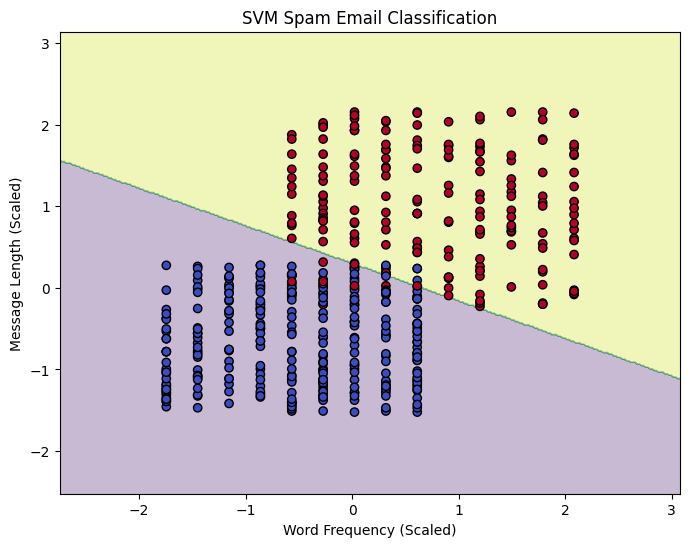

In [11]:
X_vis=scaler.transform(X)

x_min,x_max=X_vis[:,0].min()-1,X_vis[:,0].max()+1
y_min,y_max=X_vis[:,1].min()-1,X_vis[:,1].max()+1

xx,yy=np.meshgrid(
    np.arange(x_min,x_max,0.02),
    np.arange(y_min,y_max,0.02)
)
Z=classifier.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)
plt.figure(figsize=(8,6))
plt.contourf(xx,yy,Z,alpha=0.3)
plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=y,
    cmap="coolwarm",
    edgecolors="k"
)
plt.title("SVM Spam Email Classification")
plt.xlabel("Word Frequency (Scaled)")
plt.ylabel("Message Length (Scaled)")

plt.show()